In [ ]:
import os

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance

import seaborn as sns
import matplotlib.pyplot as plt

import joblib

RANDOM_SEED = 42
IMAGE_DIR = "../../results/images/LogisticRegression"
DATASET_DIR = "../../data/processed/supervised/"

os.makedirs(IMAGE_DIR, exist_ok=True)

In [10]:
train_df = pd.read_csv(f'{DATASET_DIR}/train_data.csv')
val_df = pd.read_csv(f'{DATASET_DIR}/val_data.csv')
test_df = pd.read_csv(f'{DATASET_DIR}/test_data.csv')

In [11]:
X_train = train_df.drop('fraud', axis=1)
y_train = train_df['fraud']

X_val = val_df.drop('fraud', axis=1)
y_val = val_df['fraud']

X_test = test_df.drop('fraud', axis=1)
y_test = test_df['fraud']

In [12]:
results = []

for C in [0.01, 0.1, 1, 10, 100]:
    model = LogisticRegression(C=C, 
                               max_iter=1000,
                               penalty="l2",
                               solver="lbfgs",
                               class_weight={0: 1, 1: 10},
                               random_state=RANDOM_SEED)
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    probs_val = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    perc = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)

    roc_auc = roc_auc_score(y_val, probs_val)
    pr_auc = average_precision_score(y_val, probs_val)

    results.append({
        "C": C,
        "accuracy": acc,
        "precision": perc,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
        })


c:\Users\niall\OneDrive - University of Limerick\UL\Sem6\CS4136\Hackathon\Fraud-Transaction-Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\niall\OneDrive - University of Limerick\UL\Sem6\CS4136\Hackathon\Fraud-Transaction-Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\niall\OneDrive - University of 

In [13]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="pr_auc", ascending=False)

results_df

,C,accuracy,precision,recall,f1_score,roc_auc,pr_auc
2,1.00,0.994766,0.698337,0.918750,0.793522,0.997822,0.904888
4,100.00,0.994687,0.694795,0.917708,0.790844,0.997744,0.904737
3,10.00,0.994709,0.695584,0.918750,0.791741,0.997741,0.904526
1,0.10,0.994709,0.695893,0.917708,0.791554,0.997908,0.903023
0,0.01,0.994196,0.675760,0.903125,0.773072,0.997645,0.881191


In [14]:
best_results = results_df.iloc[0]

print("Validation C:", best_results["C"])
print("Validation accuracy:", best_results["accuracy"])
print("Validation precision:", best_results["precision"])
print("Validation recall:", best_results["recall"])
print("Validation f1:", best_results["f1_score"])
print("Validation ROC AUC:", best_results["roc_auc"])
print("Validation PR AUC:", best_results["pr_auc"])

Validation C: 1.0
Validation accuracy: 0.9947663679277553
Validation precision: 0.6983372921615202
Validation recall: 0.91875
Validation f1: 0.7935222672064778
Validation ROC AUC: 0.9978221934971909
Validation PR AUC: 0.9048878621356765


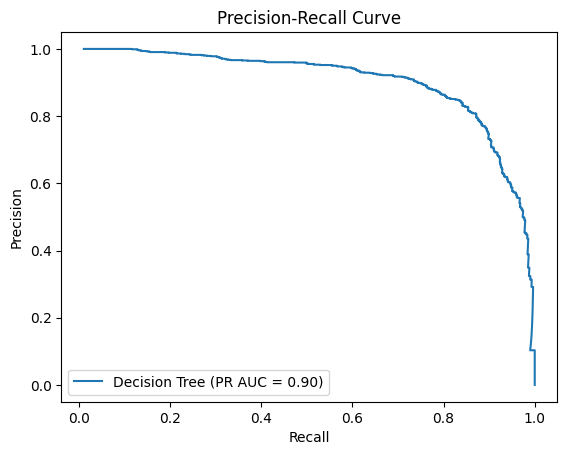

In [15]:
precision, recall, thresholds = precision_recall_curve(y_val, probs_val)

plt.plot(precision, recall, label=f'Decision Tree (PR AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig(f'{IMAGE_DIR}/pr_curve_validation.svg')
plt.show()

In [16]:
beta = 2    # Makes F2 score, puts more emphasis on recall
fbeta_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-8)

best_idx = fbeta_scores.argmax()
best_threshold = thresholds[best_idx]

In [17]:
train_val_df = pd.concat([train_df, val_df], ignore_index=True)

X_train_val = train_val_df.drop('fraud', axis=1)
y_train_val = train_val_df['fraud']

model_final = LogisticRegression(
    C=best_results["C"],
    max_iter=1000,
    penalty="l2",
    solver="lbfgs",
    class_weight={0: 1, 1: 10},
    random_state=RANDOM_SEED)

model_final.fit(X_train_val, y_train_val)
joblib.dump(model_final, "../../results/models/logistic_regression.pkl")

y_test_pred = model_final.predict(X_test)
y_test_prob = model_final.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

pr_auc = average_precision_score(y_test, y_test_prob)
roc_auc = roc_auc_score(y_test, y_test_prob)

print("Test accuracy:", accuracy)
print("Test precision:", precision)
print("Test recall:", recall)
print("Test f1:", f1)

print("Test PR AUC:", pr_auc)
print("Test ROC AUC:", roc_auc)

c:\Users\niall\OneDrive - University of Limerick\UL\Sem6\CS4136\Hackathon\Fraud-Transaction-Detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Test accuracy: 0.9949490981334111
Test precision: 0.7053140096618358
Test recall: 0.9125
Test f1: 0.7956403269754768
Test PR AUC: 0.9067765825338822
Test ROC AUC: 0.9979596414888103


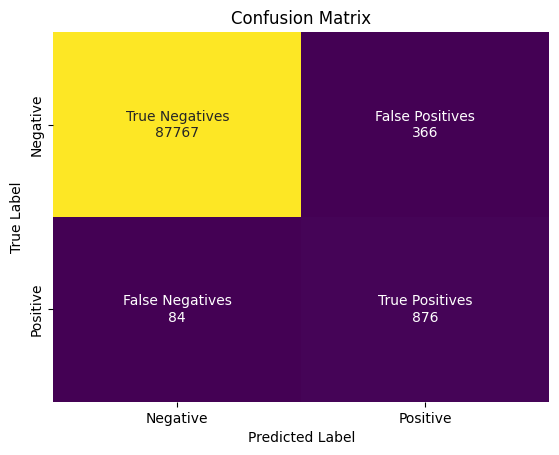

In [18]:
cf_matrix = confusion_matrix(y_test, y_test_pred)

group_names = ["True Negatives", "False Positives", "False Negatives", "True Positives"]

group_counts = ["{0:0.0f}".format(value) for value in cf_matrix.flatten()]

labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names,group_counts)]
labels = np.array(labels).reshape(2,2)

matrix = sns.heatmap(cf_matrix, annot=labels, fmt='', cmap="viridis", cbar=False)
matrix.set_xlabel("Predicted Label")
matrix.set_ylabel("True Label")
matrix.set_xticklabels(["Negative", "Positive"])
matrix.set_yticklabels(["Negative", "Positive"])
plt.title('Confusion Matrix')
plt.savefig(f"{IMAGE_DIR}/confusion_matrix.svg")
plt.show()

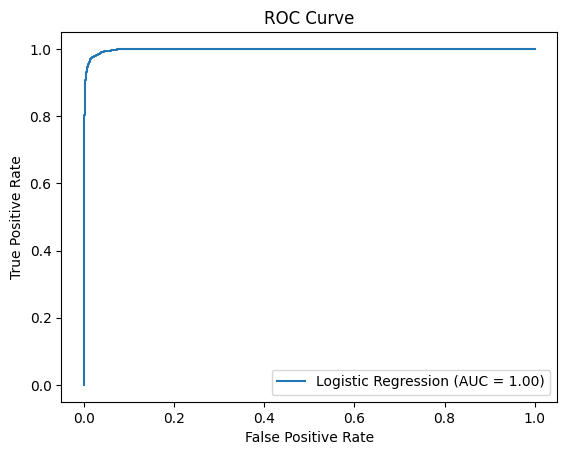

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig(f'{IMAGE_DIR}/roc_curve_test.svg')
plt.show()

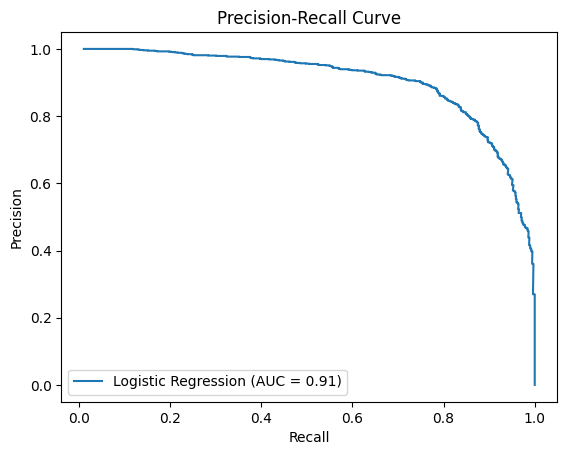

In [20]:
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)

plt.plot(precision, recall, label=f'Logistic Regression (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig(f'{IMAGE_DIR}/pr_curve_test.svg')
plt.show()

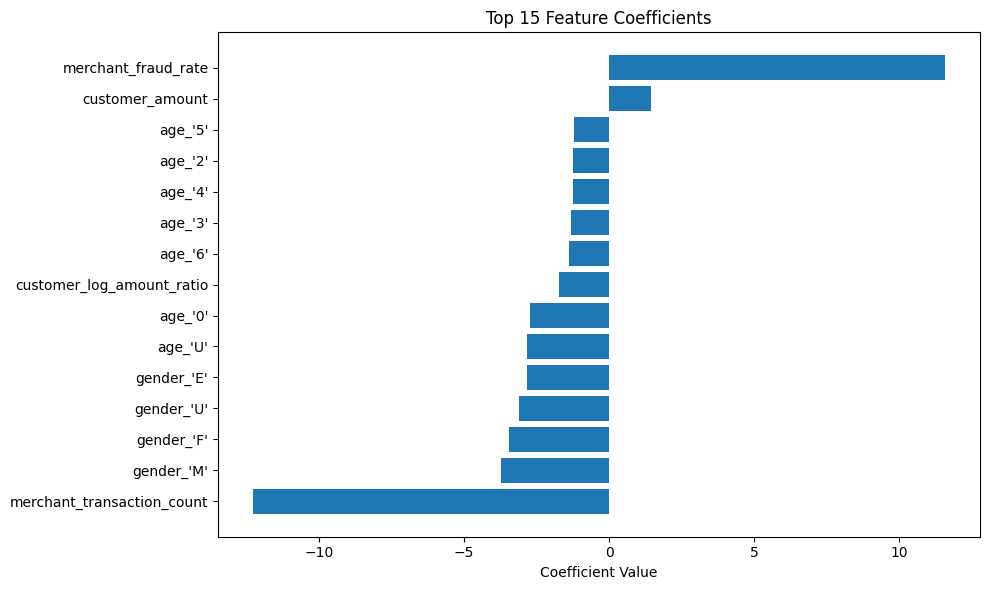

In [22]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model_final.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values(by="abs_coefficient", ascending=False)

top_coefs = coef_df.head(15).sort_values(by="coefficient", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_coefs["feature"], top_coefs["coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Top 15 Feature Coefficients")
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/feature_importance.svg')
plt.show()



In [ ]:
result = permutation_importance(
    model_final, 
    X_test, 
    y_test, 
    n_repeats=10, 
    random_state=RANDOM_SEED,
    n_jobs=-1
)

perm_imp = pd.Series(result.importances_mean, index=X_test.columns)
perm_imp = perm_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
perm_imp.sort_values().plot(kind='barh')
plt.title("Permutation Feature Importances")
plt.xlabel("Decrease in Model Performance")
plt.tight_layout()
plt.savefig(f'{IMAGE_DIR}/permutation_importance.svg')
plt.show()